# JUNE 25th-anniversary analysis — Step 4: topics

**What this does:** starts with a quick look (the most common keywords, as a
bar chart and a word cloud), then looks at what JUNE articles are about, two ways:

1. **Author keywords.** Counts the keywords authors chose, after merging
   obvious variants ("case studies" = "case study") and dropping generic ones
   ("neuroscience", "undergraduate"). Simple, but authors pick keywords freely,
   so even the most common keyword appears on only ~10% of articles.
2. **Topic groups.** A standard method (NMF, "non-negative matrix
   factorization") reads each article's title, keywords, and abstract and
   finds groups of words that tend to appear together. Each group is a topic;
   each article gets a score for every topic, and its highest score is its
   **main topic**. The computer finds the groups; **people name them.**

Both are counted by **era** (groups of volumes) to see how topics changed.
Workshop articles are included.

**What you need to do:**
1. Run each cell from top to bottom (under a minute).
2. Read the topic list under "Check the results" — each topic's top words
   and example titles — and give each topic a short name in `TOPIC_NAMES`
   in the Settings cell. Then run again.

**What goes in:** `data/june_matched.csv` (from Step 2)

**What comes out** (in the `data/` folder):
- `june_topics.csv` — one row per article: era, main topic, and topic scores
- `topic_words.csv` — one row per topic: name, top words, example titles
- `keyword_counts.csv` — how often each keyword is used, overall and by era

and, in `figures/`: `keywords_top25.png` and `keywords_wordcloud.png`

## Running in Google Colab

If you opened this notebook from the "Open in Colab" link, run the next cell
first. It downloads the project's files from GitHub (the CSVs from earlier
steps and `manual_fixes.csv`) so the rest of the notebook can find them.
On your own computer, the cell does nothing.

**Colab forgets everything when the session ends.** To keep a result, download
it from the Files panel (folder icon on the left). Make hand corrections in
`manual_fixes.csv` on GitHub, not in Colab, so they aren't lost.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules and not os.path.exists("manual_fixes.csv"):
    if not os.path.exists("JUNE_Utilities"):
        subprocess.run(["git", "clone", "https://github.com/ajuavinett/JUNE_Utilities.git"], check=True)
    os.chdir("JUNE_Utilities")
    print("Working in", os.getcwd())

## Settings — the only cell you should normally need to edit

In [2]:
MATCHED_CSV = "data/june_matched.csv"
TOPICS_CSV = "data/june_topics.csv"
TOPIC_WORDS_CSV = "data/topic_words.csv"
KEYWORDS_CSV = "data/keyword_counts.csv"

# Which kinds of items to include. Editorials and media reviews are left out
# for now: most editorials aren't about a teaching topic, and most media
# reviews have no abstract (see OPEN_QUESTIONS.md).
ITEM_TYPES = ["article", "case study", "technical"]

# Eras, as ranges of volumes (first, last)
ERAS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 24)]

# How many topic groups to look for. 15 gave the clearest groups when we tried
# 10, 12, and 15. Changing this (or ITEM_TYPES) renumbers the topics, so
# TOPIC_NAMES below would need to be redone.
N_TOPICS = 15

# Names for the topics, by number, filled in by people after reading the
# topic list. Topics without a name are shown as "Topic 3", etc.
TOPIC_NAMES = {}

# Keywords too general to tell us anything
GENERIC_KEYWORDS = {
    "neuroscience", "neuroscience education", "undergraduate", "undergraduates",
    "education", "undergraduate education", "undergraduate neuroscience",
    "undergraduate neuroscience education", "teaching", "teaching neuroscience",
    "higher education", "pedagogy", "neuroscience pedagogy", "teaching methods",
}

# Keywords that mean the same thing: "variant": "keep this one"
# (Plurals are merged automatically, e.g. "action potentials" → "action potential".)
KEYWORD_SYNONYMS = {
    "case studies": "case study",
    "caenorhabditis elegans": "c. elegans",
    "electroencephalography": "eeg",
    "electroencephalography (eeg)": "eeg",
    "electroencephalogram (eeg)": "eeg",
    "course-based undergraduate research experience": "cure",
    "course-based undergraduate research experiences": "cure",
    "course-based undergraduate research experience (cure)": "cure",
}

# Words too common in JUNE articles to help tell topics apart
# (on top of ordinary English words like "the" and "and")
EXTRA_STOP_WORDS = {
    "students", "student", "undergraduate", "undergraduates", "neuroscience",
    "course", "courses", "study", "use", "used", "using", "class", "classroom",
    "paper", "article", "describe", "described", "present", "presented",
    "provide", "provides", "also", "well", "can", "may", "one", "two", "new",
    "based", "including", "program", "programs", "education", "educational",
    "teaching", "learning", "results", "research",
}

## Setup (no need to edit below this line)

In [3]:
import re

import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer


def era_label(first, last, df):
    years = df.loc[df["volume"].between(first, last), "year_label"]
    span = f"{years.min()}–{years.max()}" if len(years) else "no items"
    return f"Vol {first}–{last} ({span})"


def add_eras(df):
    labels = {}
    for first, last in ERAS:
        label = era_label(first, last, df)
        for v in range(first, last + 1):
            labels[v] = label
    df["era"] = df["volume"].map(labels)
    return df, [era_label(f, l, df) for f, l in ERAS]

## Quick look: the most common keywords

A simple count of author keywords. Each keyword is lowercased, merged with
its variants ("case studies" → "case study", "neurons" → "neuron", and the
pairs listed in `KEYWORD_SYNONYMS`), and generic ones in `GENERIC_KEYWORDS`
(like "neuroscience") are left out. Part 1 below uses the same cleaning.

Saved as `figures/keywords_top25.png`.

508 articles use 1835 different keywords (1431 of them only once).


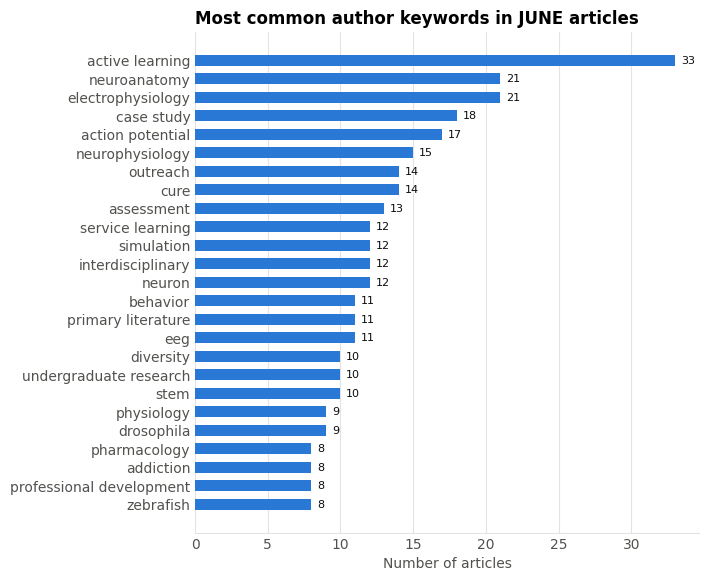

In [4]:
import os

import matplotlib.pyplot as plt

def clean_keywords(text, all_keywords=None):
    out = []
    for k in str(text).split(";"):
        k = re.sub(r"\s+", " ", k).strip().lower().rstrip(".")
        k = KEYWORD_SYNONYMS.get(k, k)
        # merge plurals: "action potentials" → "action potential", if the singular is used too
        if all_keywords and k.endswith("s") and k[:-1] in all_keywords:
            k = k[:-1]
        if k and k not in GENERIC_KEYWORDS:
            out.append(k)
    return sorted(set(out))


quick = pd.read_csv(MATCHED_CSV, keep_default_na=False, dtype=str, encoding="utf-8-sig")
quick = quick[quick["item_type"].isin(ITEM_TYPES)]

# Each article's cleaned keywords, then count how many articles use each one
first_pass = {k for text in quick["keywords"] for k in clean_keywords(text)}
keyword_lists = quick["keywords"].apply(lambda text: clean_keywords(text, first_pass))
keyword_count = keyword_lists.explode().dropna().value_counts()
print(f"{len(quick)} articles use {len(keyword_count)} different keywords "
      f"({(keyword_count == 1).sum()} of them only once).")

top = keyword_count.head(25)[::-1]    # reversed so the most common is at the top
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.barh(top.index, top.values, height=0.6, color="#2a78d6")
for y, n in enumerate(top.values):
    ax.text(n + 0.4, y, str(n), va="center", fontsize=8, color="#0b0b0b")
ax.set_xlabel("Number of articles", color="#52514e")
ax.set_title("Most common author keywords in JUNE articles", loc="left", fontweight="bold")
ax.tick_params(colors="#52514e", length=0)
ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#e4e3df")
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/keywords_top25.png", dpi=300, bbox_inches="tight")
plt.show()

## Quick look: word cloud

The same keyword counts as a word cloud: the more articles use a keyword,
the bigger (and darker) it is. Word clouds are good for a first impression
but hard to read precisely; use the bar chart above for actual numbers.

Saved as `figures/keywords_wordcloud.png`. Uses the `wordcloud` package;
the cell installs it automatically the first time if it's missing.

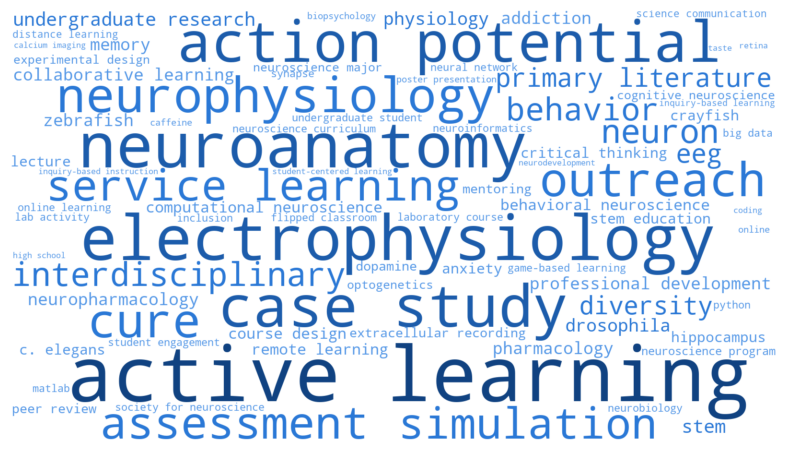

In [5]:
import subprocess
import sys

# Install the word-cloud package the first time it's needed (in Colab or anywhere)
try:
    from wordcloud import WordCloud
except ImportError:
    print("Installing the 'wordcloud' package (one time only)…")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wordcloud"], check=True)
    from wordcloud import WordCloud

shades = ["#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # light blue → dark blue
most = keyword_count.max()

def keyword_color(word, **kwargs):
    # more common keywords get darker shades
    return shades[min(3, int(4 * keyword_count[word] / most))]

cloud = WordCloud(width=1600, height=900, background_color="white", max_words=80,
                  prefer_horizontal=1.0, random_state=0, color_func=keyword_color,
                  ).generate_from_frequencies(keyword_count.head(80).to_dict())
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.imshow(cloud, interpolation="bilinear")
ax.axis("off")
fig.savefig("figures/keywords_wordcloud.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 1: author keywords

Each article's keywords are cleaned the same way as in the quick look above
(`clean_keywords`). We then count, for each era, the
**percentage of articles** using each keyword (eras have different numbers
of articles, so raw counts would mislead).

In [6]:
def count_keywords(df, era_order):
    first_pass = {k for text in df["keywords"] for k in clean_keywords(text)}
    df["keyword_list"] = df["keywords"].apply(lambda t: clean_keywords(t, first_pass))
    long = df[["item_id", "era", "keyword_list"]].explode("keyword_list").dropna()
    counts = long.groupby("keyword_list").size().rename("articles")
    per_era = (long.groupby(["keyword_list", "era"]).size().unstack(fill_value=0)
               .div(df.groupby("era").size(), axis=1).mul(100).round(1))
    per_era = per_era.reindex(columns=era_order).add_prefix("% of articles, ")
    table = pd.concat([counts, per_era], axis=1).sort_values("articles", ascending=False)
    table.index.name = "keyword"
    return table

## Part 2: topic groups

1. Each article's title, keywords, and abstract become one block of text.
2. We count words and two-word phrases ("action potential"), giving more
   weight to words that are common in *this* article but rare overall
   ("TF-IDF"). Words in more than 40% of articles, or in fewer than 4, are
   ignored.
3. NMF finds `N_TOPICS` groups of words that tend to occur together.
   `random_state=0` makes the result the same every run.

In [7]:
def find_topics(df):
    text = (df["title"] + ". " + df["keywords"].str.replace(";", ",") + ". " + df["abstract"]).str.lower()
    vectorizer = TfidfVectorizer(stop_words=list(ENGLISH_STOP_WORDS | EXTRA_STOP_WORDS),
                                 ngram_range=(1, 2), min_df=4, max_df=0.4,
                                 token_pattern=r"(?u)\b[a-z][a-z-]+\b")
    X = vectorizer.fit_transform(text)
    model = NMF(n_components=N_TOPICS, random_state=0, init="nndsvda", max_iter=500)
    scores = model.fit_transform(X)
    words = np.array(vectorizer.get_feature_names_out())
    top_words = [", ".join(words[row.argsort()[::-1][:10]]) for row in model.components_]
    return scores, top_words


def topic_name(t):
    return TOPIC_NAMES.get(t, f"Topic {t}")

## Run everything

In [8]:
def build_topics():
    df = pd.read_csv(MATCHED_CSV, keep_default_na=False, dtype=str, encoding="utf-8-sig")
    df["volume"] = df["volume"].astype(int)
    df["year_label"] = df["year_label"].astype(int)
    df = df[df["item_type"].isin(ITEM_TYPES)].reset_index(drop=True)
    df, era_order = add_eras(df)
    print(f"{len(df)} items ({', '.join(ITEM_TYPES)})")
    print(df.groupby("era").size().reindex(era_order).to_string())

    keywords = count_keywords(df, era_order)
    keywords.to_csv(KEYWORDS_CSV, encoding="utf-8-sig")

    scores, top_words = find_topics(df)
    df["main_topic"] = scores.argmax(axis=1)
    df["main_topic_name"] = df["main_topic"].map(topic_name)
    # Items with no usable text get all-zero scores; don't pretend they have a topic
    no_text = scores.sum(axis=1) == 0
    df.loc[no_text, ["main_topic", "main_topic_name"]] = [-1, "(no text)"]
    score_cols = [f"score_topic_{t}" for t in range(N_TOPICS)]
    df[score_cols] = scores.round(4)

    cols = ["item_id", "year_label", "volume", "issue", "era", "item_type", "is_fun_workshop",
            "title", "main_topic", "main_topic_name"] + score_cols
    df[cols].to_csv(TOPICS_CSV, index=False, encoding="utf-8-sig")

    topics = pd.DataFrame({
        "topic": range(N_TOPICS),
        "name": [topic_name(t) for t in range(N_TOPICS)],
        "articles (main topic)": [(df["main_topic"] == t).sum() for t in range(N_TOPICS)],
        "top words": top_words,
        "example titles": [" | ".join(df.loc[scores[:, t].argsort()[::-1][:3], "title"].str.slice(0, 90))
                           for t in range(N_TOPICS)],
    })
    topics.to_csv(TOPIC_WORDS_CSV, index=False, encoding="utf-8-sig")

    print(f"\nDone → {TOPICS_CSV}, {TOPIC_WORDS_CSV}, {KEYWORDS_CSV}")
    return df, topics, keywords, era_order


articles, topics, keywords, era_order = build_topics()

508 items (article, case study, technical)
era
Vol 1–5 (2002–2007)       50
Vol 6–10 (2007–2012)      84
Vol 11–15 (2012–2017)    136
Vol 16–20 (2017–2022)    152
Vol 21–24 (2022–2026)     86

Done → data/june_topics.csv, data/topic_words.csv, data/keyword_counts.csv


## Check the results

**Name the topics:** read each topic's top words and example titles below,
then add names to `TOPIC_NAMES` in the Settings cell, e.g.
`TOPIC_NAMES = {0: "Primary literature & writing", 1: "Lab methods", ...}`

In [9]:
pd.set_option("display.max_colwidth", 200)
topics

,topic,name,articles (main topic),top words,example titles
0,0,Topic 0,16,"writing, scientific, literature, primary, primary literature, assignment, communication, peer, articles, review",“Brevity is the Soul of Wit”: Use of a Stepwise Project to Teach Concise Scientific Writin | PopScience: Teaching Students to Communicate Scientific Findings to the General Public | Using Rubrics ...
1,1,Topic 1,66,"laboratory, data, behavioral, animal, experimental, design, analysis, lab, techniques, projects",Experimental Methods in Neuroscience: An Undergraduate Neuroscience Laboratory Course for | The Behavioral Effects of Oral Psychostimulant Ingestion on a Laboratory Rat Sample: An Un | The Studen...
2,2,Topic 2,22,"case, case studies, studies, neuroanatomy, primary, cases, patient, symptoms, adapted, neurological",The Use of Case Studies in Teaching Undergraduate Neuroscience | Effective Use of Student-Created Case Studies as Assessment in an Undergraduate Neuroscien | Sleepy Mice Case Study: Implementation...
3,3,Topic 3,28,"brain, allen, data, allen brain, neuroanatomy, atlas, brain atlas, open, cure, big",A Self-Study Tutorial using the Allen Brain Explorer and Brain Atlas to Teach Concepts of | The Allen Brain Atlas as a Resource for Teaching Undergraduate Neuroscience | A Course-Based Research E...
4,4,Topic 4,27,"fun, faculty, workshop, june, college, survey, summer, workshops, sfn, july",Expanding Collaborations between the Neuroscience Training Committee of the Society for Ne | IFEL TOUR: A Description of the Introduction to FUN Electrophysiology Labs Workshop at Bow | The New Bl...
5,5,Topic 5,30,"online, lab, video, in-person, virtual, instruction, pandemic, remote, resources, labs","Online Neuroscience Instruction: Insights, Lessons Learned, and Moving Forward | A Resource to Future Proof the Laboratory in Uncertain Times | Dual Format Course Design: Neuroanatomy and Neurophy..."
6,6,Topic 6,27,"action, potentials, potential, recording, action potential, action potentials, neurophysiology, nerve, extracellular, responses",Application of a Spike Sorting Procedure to Analyze Recordings in the Crayfish Ventral Sup | Technical Note: Construction of a Simple Suction Electrode for Extracellular Recording and | Action Pot...
7,7,Topic 7,32,"outreach, school, community, service, high school, high, college, activities, awareness, university",Effects of a Service-Learning Neuroscience Course on Mood and Intergroup Anxiety | Everyday Neuroscience: A Community Engagement Course | Integrating Community Outreach into the Undergraduate Neur...
8,8,Topic 8,13,"eeg, cognitive, electroencephalography eeg, electroencephalography, erp, laboratory, event-related, equipment, electroencephalogram, fmri",Incorporating an ERP Project into Undergraduate Instruction | Recommendations for Developing an EEG Laboratory at a Primarily Undergraduate Institution | Virtual EEG: A Software-Based Electroencep...
9,9,Topic 9,26,"exercise, taste, laboratory exercise, sensory, perception, sensation, laboratory, sweet, processing, fruit",The Miracle Fruit: An Undergraduate Laboratory Exercise in Taste Sensation and Perception | Use of Buzz Buttons to Illustrate Taste Perception Principles in a Sensation and Perceptio | Use of the ...


In [10]:
# Most-used keywords, and the % of each era's articles that use them
keywords.head(30)

,articles,"% of articles, Vol 1–5 (2002–2007)","% of articles, Vol 6–10 (2007–2012)","% of articles, Vol 11–15 (2012–2017)","% of articles, Vol 16–20 (2017–2022)","% of articles, Vol 21–24 (2022–2026)"
keyword,,,,,,
active learning,33,0.0,0.0,6.6,10.5,9.3
neuroanatomy,21,4.0,6.0,1.5,5.3,4.7
electrophysiology,21,2.0,0.0,6.6,5.3,3.5
case study,18,2.0,0.0,3.7,5.9,3.5
action potential,17,4.0,4.8,2.9,2.6,3.5
neurophysiology,15,4.0,2.4,2.9,2.6,3.5
outreach,14,0.0,1.2,2.9,2.6,5.8
cure,14,0.0,0.0,0.0,5.3,7.0
assessment,13,0.0,1.2,2.9,3.9,2.3


In [11]:
# % of each era's articles whose main topic is each topic
share = (pd.crosstab(articles["main_topic_name"], articles["era"], normalize="columns")
         .mul(100).round(1).reindex(columns=era_order))
share["all eras"] = (articles["main_topic_name"].value_counts(normalize=True) * 100).round(1)
share.sort_values("all eras", ascending=False)

era,Vol 1–5 (2002–2007),Vol 6–10 (2007–2012),Vol 11–15 (2012–2017),Vol 16–20 (2017–2022),Vol 21–24 (2022–2026),all eras
main_topic_name,,,,,,
Topic 10,12.0,14.3,17.6,11.8,16.3,14.6
Topic 1,28.0,22.6,6.6,11.2,8.1,13.0
Topic 12,2.0,2.4,8.8,7.9,15.1,7.9
Topic 13,10.0,7.1,7.4,6.6,10.5,7.9
Topic 11,8.0,8.3,4.4,9.2,8.1,7.5
Topic 7,2.0,6.0,8.1,6.6,5.8,6.3
Topic 5,6.0,3.6,2.9,10.5,4.7,5.9
Topic 14,4.0,4.8,7.4,5.3,5.8,5.7
Topic 3,0.0,3.6,2.9,9.9,7.0,5.5


In [12]:
# Workshop vs. other articles: % with each main topic
(pd.crosstab(articles["main_topic_name"], articles["is_fun_workshop"].map({"True": "workshop", "False": "other"}),
             normalize="columns").mul(100).round(1))

is_fun_workshop,other,workshop
main_topic_name,,
Topic 0,3.6,1.7
Topic 1,14.8,7.0
Topic 10,13.2,19.1
Topic 11,6.9,9.6
Topic 12,8.4,6.1
Topic 13,8.4,6.1
Topic 14,5.9,5.2
Topic 2,5.1,1.7
Topic 3,5.3,6.1
